In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import wasserstein_distance

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from optimize.strategies import LUTProbabilisticSimulation
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

print("Environment initialized.")

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax
Environment initialized.


In [10]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

ELECTRON_SAMPLING_RESOLUTION = 0.1
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# --- Setup Parameters ---
ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH
)

response, ref_params = load_lut(LUT_FILE, ref_params)
strategy = LUTProbabilisticSimulation(response)

print("Configuration complete.")

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Configuration complete.


In [18]:
# --- Load Data ---
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1, max_nbatch=2, max_batch_len=300,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=1)

# Aggregate tracks from batches
all_tracks = []
track_fields = dataset.get_track_fields()
for i in range(len(dataloader)):
    all_tracks.append(dataloader[i].reshape(-1, len(track_fields)))
tracks = jnp.concatenate(all_tracks, axis=0)

print(f"Loaded {tracks.shape[0]} track segments.")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 553.6951837539673 cm.
INFO:optimize.dataio:-- The number of simulation batches is 2.


Loaded 7972 track segments.


In [19]:
def get_feature_samples(params):
    """Runs simulation and returns a dict of weighted samples for each feature."""
    output = strategy.predict(params, tracks, track_fields, 42)
    
    # hit_prob: (Npix, Nhits, Nticks)
    # adcs_distrib: (Npix, Nhits, Nticks)
    prob = jnp.exp(output['hit_prob']) # Probabilistic mode returns log-prob
    adcs = output['adcs_distrib']
    pix_x = output['pixel_x']
    pix_y = output['pixel_y']
    
    # Flatten and threshold to get meaningful samples
    threshold = 1e-4
    mask = prob > threshold
    
    # Extraction helper
    def get_weighted_flat(arr_per_pix, weight_mask, weights):
        broad = jnp.broadcast_to(arr_per_pix[:, None, None], weights.shape)
        return broad[weight_mask], weights[weight_mask]

    # Charge distribution samples
    charge_vals = adcs[mask]
    charge_weights = prob[mask]
    
    # Time (tick) distribution samples
    ticks_arr = jnp.arange(prob.shape[-1])
    tick_broad = jnp.broadcast_to(ticks_arr[None, None, :], prob.shape)
    time_vals = tick_broad[mask]
    time_weights = prob[mask]
    
    # Spatial distribution samples
    x_vals, x_weights = get_weighted_flat(pix_x, mask, prob)
    y_vals, y_weights = get_weighted_flat(pix_y, mask, prob)
    
    # Triggered Pixels (Sum probability per pixel)
    pix_sum_prob = jnp.sum(prob, axis=(1, 2))
    
    return {
        'charge': (charge_vals, charge_weights),
        'time': (time_vals, time_weights),
        'x': (x_vals, x_weights),
        'y': (y_vals, y_weights),
        'pix_counts': pix_sum_prob
    }

print("Feature extraction logic defined.")

Feature extraction logic defined.


In [20]:
def compare_distributions(samples_ref, samples_shift, feature_name):
    """Calculates distance metrics between nominal and shifted distributions."""
    if feature_name == 'pix_counts':
        v_ref = np.array(samples_ref)
        v_shift = np.array(samples_shift)
        w_dist = wasserstein_distance(v_ref, v_shift)
        h_ref, bins = np.histogram(v_ref, bins=50, density=True)
        h_shift, _ = np.histogram(v_shift, bins=bins, density=True)
        mse = np.mean((h_ref - h_shift)**2)
        return w_dist, mse
    else:
        v_ref, w_ref = samples_ref
        v_shift, w_shift = samples_shift
        v_ref, w_ref = np.array(v_ref), np.array(w_ref)
        v_shift, w_shift = np.array(v_shift), np.array(w_shift)
        w_dist = wasserstein_distance(v_ref, v_shift, w_ref, w_shift)
        f_min, f_max = v_ref.min(), v_ref.max()
        h_ref, bins = np.histogram(v_ref, bins=100, range=(f_min, f_max), weights=w_ref, density=True)
        h_shift, _ = np.histogram(v_shift, bins=bins, range=(f_min, f_max), weights=w_shift, density=True)
        mse = np.mean((h_ref - h_shift)**2)
        return w_dist, mse

print("Metrics logic defined.")

Metrics logic defined.


In [26]:
# --- Run Sensitivity Scan ---
nominal_values = {p: float(ranges[p]['nom']) for p in RELEVANT_PARAMS}
nom_params = ref_params.replace(**nominal_values)
nominal_samples = get_feature_samples(nom_params)

scan_results = {}
for p in RELEVANT_PARAMS:
    print(f"Scanning {p}...")
    p_min, p_max = float(ranges[p]['min']), float(ranges[p]['max'])
    test_values = np.linspace(p_min, p_max, 25)
    p_results = []
    for val in tqdm(test_values):
        shifted_params = nom_params.replace(**{p: val})
        shifted_samples = get_feature_samples(shifted_params)
        metrics = {}
        for feat in ['charge', 'time', 'x', 'y', 'pix_counts']:
            w_dist, mse = compare_distributions(nominal_samples[feat], shifted_samples[feat], feat)
            metrics[feat] = {'wasserstein': w_dist, 'mse': mse}
        p_results.append({'value': val, 'metrics': metrics})
    scan_results[p] = p_results

print("Scan complete.")

Scanning Ab...


  0%|          | 0/25 [00:00<?, ?it/s]

Scanning kb...


  0%|          | 0/25 [00:00<?, ?it/s]

Scanning lifetime...


...

Scanning shift_y...


  0%|          | 0/25 [00:00<?, ?it/s]

Scanning shift_z...


  0%|          | 0/25 [00:00<?, ?it/s]

Scan complete.


(75.0, 125.0)

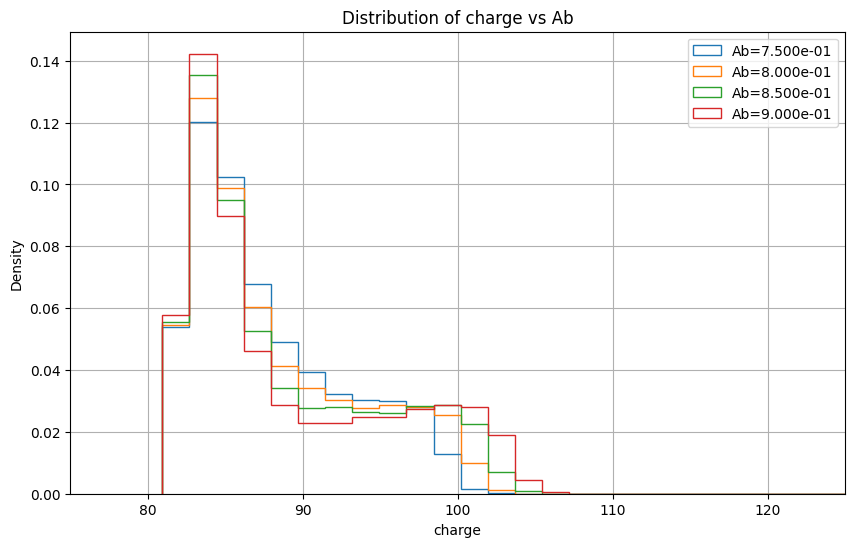

In [ ]:
# --- Qualitative Inspection: Overlaid Histograms ---
def plot_sensitivity_hists(param_to_plot, feature_to_plot, nb_to_plot=3):
    #Take even spacing of values to plot
    plt.figure(figsize=(10, 6))
    
    results = scan_results[param_to_plot]
    step = max(1, len(results) // nb_to_plot)
    results = results[::step]
    for res in results:
        val = res['value']
        shifted_p = nom_params.replace(**{param_to_plot: val})
        samples = get_feature_samples(shifted_p)[feature_to_plot]
        if feature_to_plot == 'pix_counts':
            plt.hist(np.array(samples), bins=50, histtype='step', density=True, label=f"{param_to_plot}={val:.3e}")
        else:
            v, w = samples
            plt.hist(np.array(v), bins=100, weights=np.array(w), histtype='step', density=True, label=f"{param_to_plot}={val:.3e}")
    plt.title(f"Distribution of {feature_to_plot} vs {param_to_plot}")
    plt.xlabel(feature_to_plot)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    # plt.show()

plot_sensitivity_hists('Ab', 'charge')
plt.xlim(75, 125)

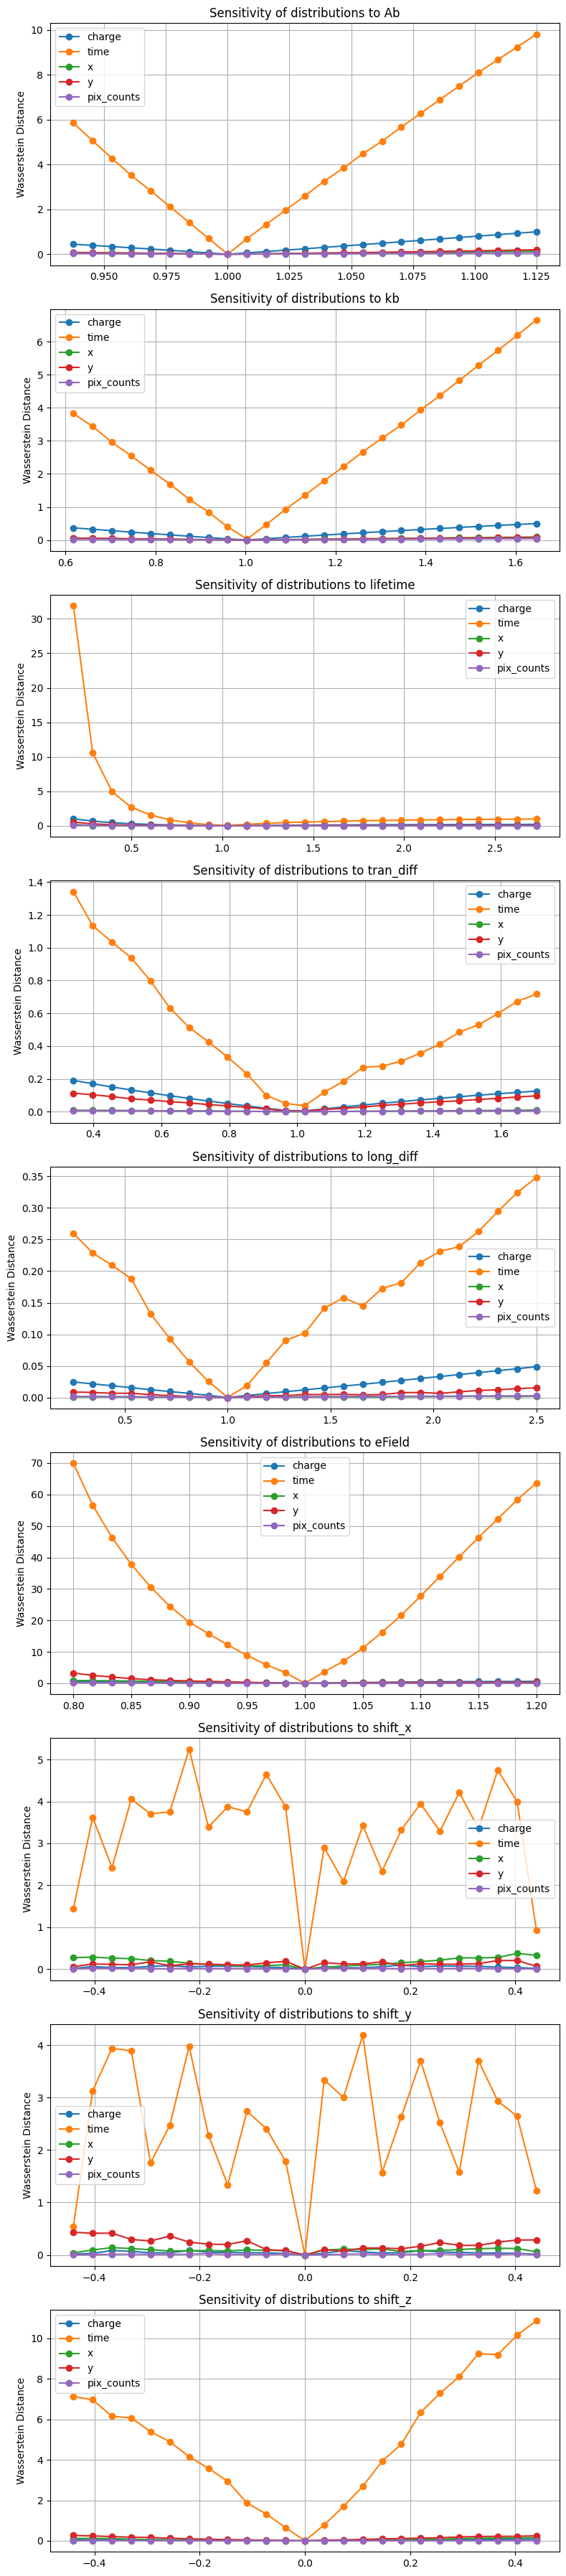

In [28]:
# --- Quantitative Sensitivity Plots ---
def plot_metric_curves(metric_name='wasserstein'):
    fig, axes = plt.subplots(len(RELEVANT_PARAMS), 1, figsize=(8, 4 * len(RELEVANT_PARAMS)))
    features = ['charge', 'time', 'x', 'y', 'pix_counts']
    for i, p in enumerate(RELEVANT_PARAMS):
        results = scan_results[p]
        test_values = [res['value'] for res in results]
        for feat in features:
            metric_vals = [res['metrics'][feat][metric_name] for res in results]
            p_nom = nominal_values[p]
            x_axis = np.array(test_values) / p_nom if p_nom != 0 else test_values
            axes[i].plot(x_axis, metric_vals, marker='o', label=feat)
        axes[i].set_title(f"Sensitivity of distributions to {p}")
        axes[i].set_ylabel(f"{metric_name.capitalize()} Distance")
        axes[i].legend()
        axes[i].grid(True)
    plt.tight_layout()
    plt.show()

plot_metric_curves('wasserstein')